In [50]:
import pandas as pd 
from tensorflow import keras 
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input,Flatten,Dense
import matplotlib.pyplot as plt 

from sklearn.model_selection import train_test_split

In [13]:
df = pd.read_csv(r'mnist_train.csv')
print(df.head(3))

   label  1x1  1x2  1x3  1x4  1x5  ...  28x23  28x24  28x25  28x26  28x27  28x28
0      5    0    0    0    0    0  ...      0      0      0      0      0      0
1      0    0    0    0    0    0  ...      0      0      0      0      0      0
2      4    0    0    0    0    0  ...      0      0      0      0      0      0

[3 rows x 785 columns]


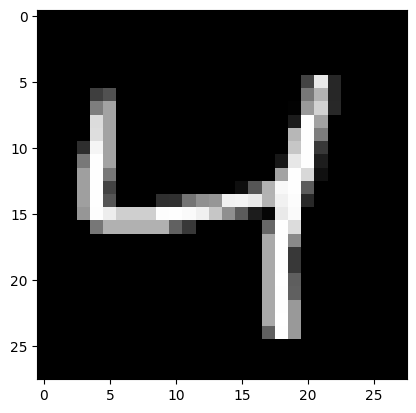

In [22]:
plt.imshow(df.iloc[2,1:].values.reshape(28,28), cmap = 'grey')


In [24]:
X = df.drop(columns = ['label'])
y= df['label']

In [26]:
X_tr,X_tst,y_tr,y_tst = train_test_split(X,y,test_size= 0.2, random_state= 43)

In [27]:
X_tr = X_tr/255
X_tst = X_tst/255

In [28]:
from tensorflow.keras.layers import Activation
model = Sequential([
     Input(shape=(784,)),
     Dense(132,activation = 'relu'),
     Dense(32,activation = 'relu'),
     Dense(10,activation='sigmoid')

])

In [29]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 132)            │       103,620 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 108,206 (422.68 KB)

 Trainable params: 108,206 (422.68 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
model.compile(loss = 'sparse_categorical_crossentropy',optimizer='Adam',metrics = ['accuracy'])


In [125]:
history  = model.fit(X_tr,y_tr,epochs = 3,validation_split= 0.2)

Epoch 1/3
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9760 - loss: 0.0022 - val_accuracy: 0.9474 - val_loss: 0.2132
Epoch 2/3
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9728 - loss: 0.0096 - val_accuracy: 0.9501 - val_loss: 0.2257
Epoch 3/3
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9751 - loss: 0.0029 - val_accuracy: 0.9520 - val_loss: 0.2035


In [126]:
y_prob= model.predict(X_tst)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [127]:
import numpy as np
y_pred = np.argmax(y_prob,axis = 1)

In [128]:
from sklearn.metrics import confusion_matrix,accuracy_score
accuracy_score(y_pred,y_tst)

0.9565

In [129]:
print(confusion_matrix(y_tst,y_pred))

[[1179    0    0    0    1    3    5    0    4    2]
 [   0 1271    4    2    1    1    0    4    4    0]
 [   2   29 1149    5    2    0    5    3    7    2]
 [   0    0   15 1166    0    2    0    3    4    1]
 [   0    3    3    0 1137    4    7    1    1   11]
 [   4    0    1   62    1 1009   10    2    7    4]
 [   9    0    1    1    3   17 1156    0    5    0]
 [  10   10   59   26    3    6    0 1193    6    5]
 [   1    6    4   16    3    8    2    1 1144    3]
 [   5    2    1   19   22    4    0   13   19 1074]]


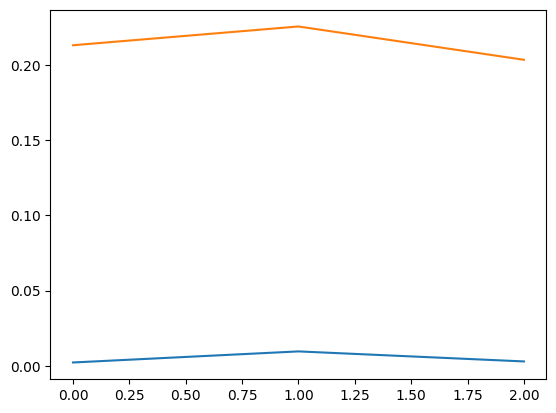

In [130]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.show()

In [131]:
df_test = pd.read_csv(r'mnist_test.csv')

In [132]:
X_tst_2 = df_test.drop(columns=['label'])
y_tst_2 = df_test['label']

In [133]:
X_tst_2 = X_tst_2/255


In [134]:
y_prob_2 = model.predict(X_tst_2)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [135]:
y_pred_2 = np.argmax(y_prob_2,axis = 1)


In [136]:
confusion_matrix(y_pred_2,y_tst_2)

array([[ 969,    0,    6,    0,    2,    2,    6,    6,    1,    3],
       [   1, 1124,   25,    0,    1,    1,    1,   15,    0,    6],
       [   0,    2,  981,    6,    6,    1,    1,   53,    6,    0],
       [   2,    1,    5,  992,    1,   64,    1,   15,   13,   21],
       [   0,    0,    2,    0,  955,    0,    6,    1,    5,    9],
       [   0,    2,    0,    5,    1,  817,   18,    2,    9,    6],
       [   6,    3,    2,    0,    4,    1,  921,    0,    1,    1],
       [   2,    1,    2,    3,    3,    2,    0,  927,    3,   12],
       [   0,    2,    8,    2,    1,    2,    4,    4,  935,   11],
       [   0,    0,    1,    2,    8,    2,    0,    5,    1,  940]])

In [137]:
print(accuracy_score(y_pred_2,y_tst_2))

0.9561
